# Project 3 — What Type of Player Is This?

## The mystery we're solving

Have you ever wondered if NBA players naturally fall into **types** — like "sharpshooting wing", "rim-running big", "primary ball-handler", "bench role player"?

Coaches and fans group players this way all the time. But here's the cool part: **could a computer figure out these types on its own, just by looking at the numbers, without anyone ever telling it that "centers" or "shooting guards" exist?**

That's exactly what we're going to do — using a technique called **clustering**. We'll feed in 13 stats per player (no labels, no positions, no names of "types") and let the algorithm find natural groups.

## What we'll do, in plain English

1. Compute each player's **season-average** stats from their game-by-game log.
2. Pick the stats that describe a player's **style** (not just how much they play).
3. **Scale** the features so big numbers don't overpower small ones.
4. Use **K-Means** to find groups of similar players.
5. Look at each group's average stats — and at the actual names inside — to figure out what type of player it represents.

## What you'll learn

- How **unsupervised learning** is different from supervised (no answer key — the algorithm finds structure on its own).
- Why **scaling** matters for distance-based algorithms.
- What **PCA** is good for (visualising high-dimensional data).
- How to choose the number of clusters with the **elbow** and **silhouette** methods.
- How to **name** clusters by reading their average stat profiles.

> **Heads-up:** this notebook builds on [Project 0 (EDA)](00_eda.ipynb) — read that first to understand the dataset.


## 1. Setup

We need a few new tools from scikit-learn:
- **`StandardScaler`** — rescales every column to mean 0, std 1.
- **`PCA`** — squashes 13-dimensional data into 2D so we can plot it.
- **`KMeans`** — the clustering algorithm.
- **`silhouette_score`** — a number that tells us "how cleanly separated are my clusters?"

`RANDOM_STATE = 42` makes our results reproducible — every run gives the same clusters, so you and a classmate get matching numbers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the data

Same dataset as the EDA notebook — one row per player per game. From EDA we already know it has 16,512 rows, 562 unique players, and no missing values.


In [2]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"

games = pd.read_csv(DATA_PATH)
games.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


## 3. Aggregate to per-player season averages

### Why aggregate?

Right now our data has 16,512 rows — one per player-game. But for clustering, we want **one row per player** (their typical performance). So we group by player and average their stats across all their games.

### Why filter to GP >= 15?

EDA Section 5 showed about 49 players have 5 or fewer games — their averages are unstable. We drop everyone with fewer than 15 games to keep the cluster results trustworthy. (Same idea as `MIN_GAMES = 20` in Project 1, just a slightly looser cutoff.)

> **What we just learned:** clustering needs one row per *thing being clustered* (here: per player). The first move in any unsupervised project is figuring out what your "thing" is and aggregating to that level.


In [3]:
stat_cols = ["MP", "FGA", "3PA", "FTA",
             "FG%", "3P%", "FT%",
             "ORB", "DRB", "TRB",
             "AST", "STL", "BLK", "TOV", "PF", "PTS"]

games_played = games.groupby("Player").size().rename("GP")

season = (
    games.groupby("Player")[stat_cols]
    .mean()
    .join(games_played)
)

MIN_GAMES = 15
players = season[season["GP"] >= MIN_GAMES].copy()
print(f"Players before filter: {len(season)}  |  after (GP ≥ {MIN_GAMES}): {len(players)}")
players.head()

Players before filter: 562  |  after (GP ≥ 15): 439


,MP,FGA,3PA,FTA,FG%,3P%,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GP
Player,,,,,,,,,,,,,,,,,
A.J. Green,21.997500,5.863636,5.045455,0.340909,0.426455,0.395273,0.140159,0.250000,2.000000,2.250000,1.272727,0.545455,0.113636,0.613636,2.113636,7.659091,44
Aaron Gordon,26.666000,8.500000,2.800000,3.233333,0.510900,0.401000,0.630700,1.533333,3.200000,4.733333,3.066667,0.466667,0.266667,1.333333,1.600000,12.333333,30
Aaron Holiday,11.371944,3.444444,2.305556,0.527778,0.345556,0.275833,0.222222,0.166667,0.777778,0.944444,1.194444,0.361111,0.111111,0.472222,1.055556,4.222222,36
Aaron Nesmith,20.949333,5.533333,2.400000,1.933333,0.478467,0.393333,0.564467,0.466667,2.866667,3.333333,1.266667,0.600000,0.266667,0.733333,2.600000,8.200000,15
Aaron Wiggins,21.322745,8.117647,3.686275,0.901961,0.475412,0.339980,0.267157,1.078431,2.490196,3.568627,1.568627,0.725490,0.235294,0.823529,1.254902,10.137255,51


## 4. Pick the right features for clustering

### What features describe "playing style"?

We want stats that tell us *how* a player plays, not *how much*. So:

**Keep:**
- **Volume rates**: `FGA`, `3PA`, `FTA` (how many shots of each type)
- **Efficiency**: `FG%`, `3P%`, `FT%`
- **Activity**: `ORB`, `DRB`, `AST`, `STL`, `BLK`, `TOV`, `PF`

**Drop:**
- `PTS` — already encoded by the attempt features (FGA + FTA + their conversions)
- `MP` and `GP` — minutes played dominates everything; star players would cluster together just because they play a lot
- `TRB` — exactly equal to `ORB + DRB`, so it's redundant (EDA Section 8 footgun)

> **What we just learned:** in clustering, feature selection is *the* design decision. Pick stats that capture what you want to discover. Including the wrong features (like minutes played) would give you a "stars vs benchwarmers" cluster instead of a "shooters vs rebounders" cluster.


In [4]:
cluster_features = ["FGA", "3PA", "FTA",
                    "FG%", "3P%", "FT%",
                    "ORB", "DRB",
                    "AST", "STL", "BLK", "TOV", "PF"]

X = players[cluster_features].fillna(0)  # rare NaN in % cols (e.g., player never shot 3s)
X.head()

,FGA,3PA,FTA,FG%,3P%,FT%,ORB,DRB,AST,STL,BLK,TOV,PF
Player,,,,,,,,,,,,,
A.J. Green,5.863636,5.045455,0.340909,0.426455,0.395273,0.140159,0.250000,2.000000,1.272727,0.545455,0.113636,0.613636,2.113636
Aaron Gordon,8.500000,2.800000,3.233333,0.510900,0.401000,0.630700,1.533333,3.200000,3.066667,0.466667,0.266667,1.333333,1.600000
Aaron Holiday,3.444444,2.305556,0.527778,0.345556,0.275833,0.222222,0.166667,0.777778,1.194444,0.361111,0.111111,0.472222,1.055556
Aaron Nesmith,5.533333,2.400000,1.933333,0.478467,0.393333,0.564467,0.466667,2.866667,1.266667,0.600000,0.266667,0.733333,2.600000
Aaron Wiggins,8.117647,3.686275,0.901961,0.475412,0.339980,0.267157,1.078431,2.490196,1.568627,0.725490,0.235294,0.823529,1.254902


## 5. Scale the features

### Why scaling matters here

K-Means measures how "close" two players are using **Euclidean distance** (the same straight-line distance you learned in geometry class).

Look at our features: `FGA` ranges from 0-25, but `FG%` ranges from 0-1. Without scaling, the distance between two players would be dominated by `FGA`. A 1-point difference in FGA would seem 25 times more important than a 1-point difference in FG%.

`StandardScaler` fixes this by transforming each feature to **mean 0, standard deviation 1**. After scaling, every feature contributes equally to the distance calculation.

### Vocab box

| Term | Plain-English meaning |
|---|---|
| **Standardisation** | Rescale every column so its mean is 0 and its standard deviation is 1. Removes scale differences. |
| **Euclidean distance** | The straight-line distance between two points, generalised to many dimensions. |

> **What we just learned:** any algorithm that uses distance (K-Means, PCA, k-Nearest-Neighbours) needs scaled features, or the largest-magnitude column will silently dominate.


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2).loc[["mean", "std"]]

,FGA,3PA,FTA,FG%,3P%,FT%,ORB,DRB,AST,STL,BLK,TOV,PF
mean,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Visualise the players with PCA

### What is PCA, in plain English?

We have 13 features per player. That's 13 dimensions — impossible to plot or visualise. **PCA (Principal Component Analysis)** is a math trick that finds the 2 directions in those 13 dimensions along which players differ the most, then projects everyone onto those 2 directions. The result is a 2D map.

The new axes are called **PC1** and **PC2** — they don't have a basketball name, but you can usually figure out what they represent (PC1 might roughly mean "shot volume", PC2 might mean "interior vs perimeter").

> **What we just learned:** PCA is your friend whenever you have many features and want to *see* the data in 2D. Even before clustering, the scatter often shows blob-like structure — a hint that natural groups exist.


Variance explained by 2 components: 72.9%


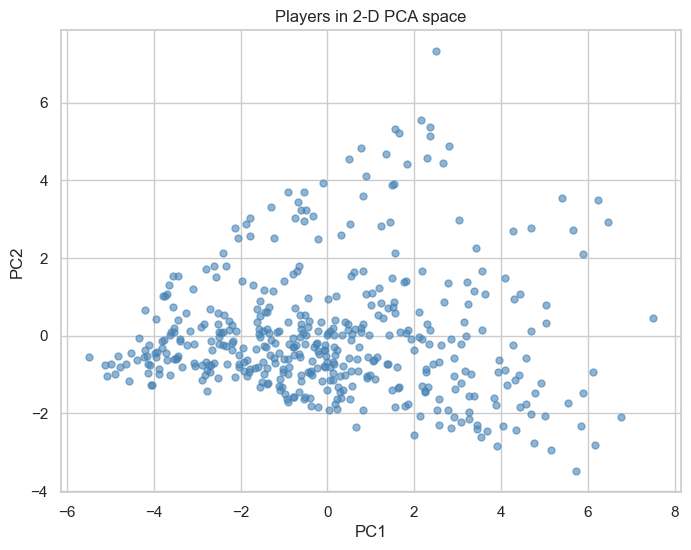

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=25, color="steelblue")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Players in 2-D PCA space")
plt.show()

## 7. How many clusters should we use?

### Two methods to pick K

K-Means doesn't pick K (the number of clusters) for you — you have to choose. We use two complementary methods:

| Method | What it measures | Read it like this |
|---|---|---|
| **Elbow** | Within-cluster sum of squares (lower = tighter clusters). Plotted vs K. | Look for the "elbow" where adding more clusters stops helping much. |
| **Silhouette score** | How well-separated clusters are (range -1 to +1, higher is better). | Pick K with the highest score. |

Both plots usually point to the same answer. If they disagree, lean toward the smaller K — fewer clusters is easier to interpret.

> **What we just learned:** picking K is half art, half science. The elbow tells you "we've extracted most of the value", the silhouette tells you "the clusters are well-separated". When both agree, you're confident.


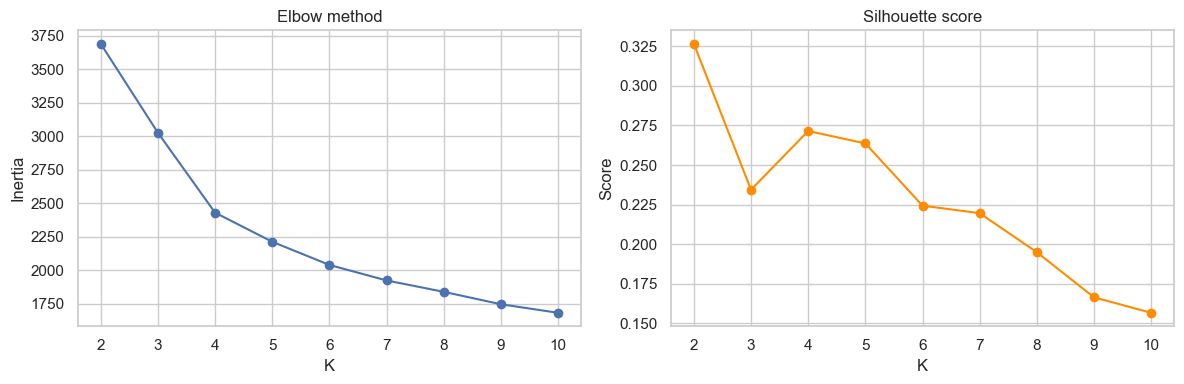

In [7]:
Ks = range(2, 11)
inertias, silhouettes = [], []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(Ks), inertias, "o-"); axes[0].set_title("Elbow method")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(Ks), silhouettes, "o-", color="darkorange")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("K"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

Both plots point to **K = 4 or K = 5**. We'll go with **K = 5** — it gives a richer set of archetypes while staying interpretable.


## 8. Fit K-Means with K=5

Now we run the actual algorithm. K-Means works in a loop:
1. Start by picking 5 random "centre points" in the data.
2. Assign every player to their nearest centre (their cluster).
3. Move each centre to the average of all the players assigned to it.
4. Repeat until the centres stop moving.

The output is a **cluster label** (0-4) attached to every player.


In [8]:
K = 5
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
players["cluster"] = kmeans.fit_predict(X_scaled)

players["cluster"].value_counts().sort_index()

cluster
0     42
1    175
2    103
3     65
4     54
Name: count, dtype: int64

### See the clusters in PCA space

Same PCA scatter as Section 6, but now we colour each player by which cluster they were assigned to. If the colours form clean regions, the clusters are coherent.


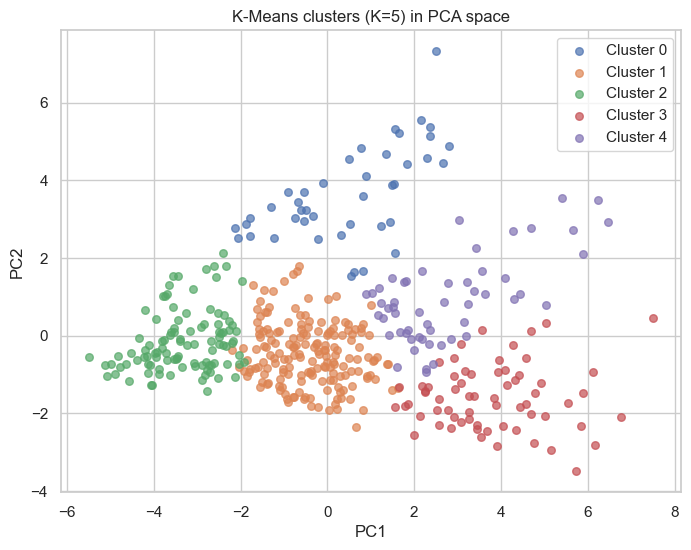

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(K):
    mask = (players["cluster"] == c).to_numpy()
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.7, s=30, label=f"Cluster {c}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"K-Means clusters (K={K}) in PCA space")
ax.legend()
plt.show()

## 9. Interpret the clusters — what does each one mean?

The cluster numbers (0-4) are meaningless on their own. To figure out what each represents, we look at the **average stats** of every player in each cluster.


In [10]:
profile = players.groupby("cluster")[cluster_features + ["PTS"]].mean().round(2)
profile

,FGA,3PA,FTA,FG%,3P%,FT%,ORB,DRB,AST,STL,BLK,TOV,PF,PTS
cluster,,,,,,,,,,,,,,
0,5.97,0.34,2.03,0.57,0.05,0.41,2.49,4.78,1.75,0.65,0.99,1.18,2.15,8.48
1,7.18,3.72,1.33,0.42,0.31,0.36,0.79,2.47,2.07,0.78,0.34,1.03,1.73,8.71
2,2.66,1.24,0.58,0.32,0.16,0.17,0.48,1.15,0.78,0.32,0.20,0.42,0.85,3.05
3,16.42,6.94,4.60,0.45,0.35,0.74,0.80,4.12,5.49,1.17,0.44,2.66,2.17,21.32
4,12.28,4.17,3.53,0.48,0.32,0.60,1.78,5.34,2.97,1.09,0.93,1.80,2.45,16.19


### A heatmap makes the patterns pop

Same numbers as the table above, but coloured: **red** = cluster is above league-average on this stat, **blue** = below. Read each row to see what makes each cluster distinct.


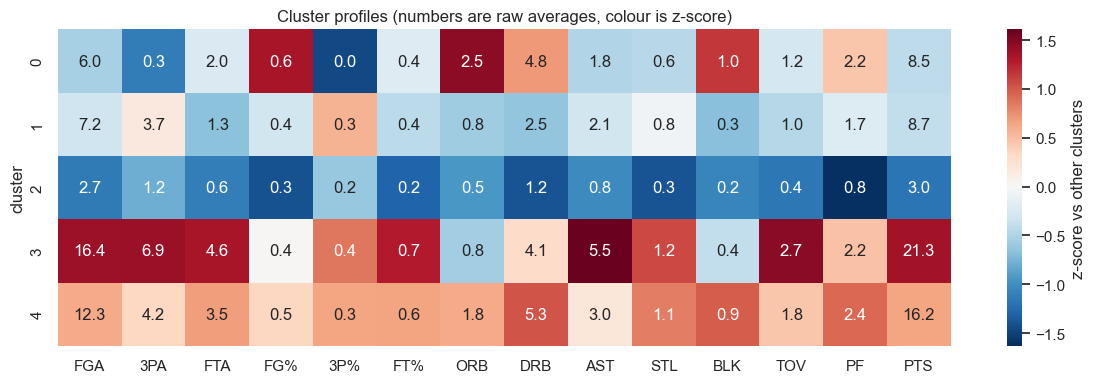

In [11]:
# Normalise so we can compare clusters on a heatmap
profile_z = (profile - profile.mean()) / profile.std()

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_z, annot=profile.round(1), fmt="", cmap="RdBu_r",
            center=0, ax=ax, cbar_kws={"label": "z-score vs other clusters"})
ax.set_title("Cluster profiles (numbers are raw averages, colour is z-score)")
plt.tight_layout(); plt.show()

### Reading our heatmap — the five archetypes

Based on which stats are red (above average) for each cluster, here's what each one represents:

| Cluster | Profile (red stats) | Archetype |
|---|---|---|
| **0** (n=42) | high `ORB`, high `BLK`, high `FG%`, low `3PA` | **Interior bigs** — centres who finish at the rim and protect it. |
| **1** (n=175) | high `3PA`, decent `3P%`, average across the board | **Wings & shooters** — the modern volume 3-point shooter. |
| **2** (n=103) | low everything (low `FGA`, low `MP`-derived stats) | **Bench / low-usage role players** — guys who don't get many touches. |
| **3** (n=65) | very high `FGA`, very high `AST`, very high `PTS`, high `TOV` | **Primary creators / star scorers** — the offence runs through them. |
| **4** (n=54) | high `FGA`, high `TRB`, high `BLK`, high `PTS` | **Two-way scoring bigs / forwards** — score *and* defend the paint. |

> **What we just learned:** raw cluster numbers (0-4) become meaningful when you read the *average stat profile* of each. The model didn't know basketball — but it found groups that match what coaches actually call "player types".


## 10. Sanity check — who's actually in each cluster?

Let's print the top scorers from each cluster and see if the names make basketball sense. If "Cluster 4 = two-way scoring bigs" is right, we should see Giannis, Wembanyama, Anthony Davis there. If we see Trae Young, something is wrong.


In [12]:
for c in range(K):
    top = (players[players["cluster"] == c]
           .sort_values("PTS", ascending=False)
           .head(8)
           .index.tolist())
    print(f"\n— Cluster {c} (n={(players['cluster']==c).sum()}) —")
    print(", ".join(top))


— Cluster 0 (n=42) —
Mark Williams, Ivica Zubac, Deandre Ayton, Jakob Poeltl, Jarrett Allen, Daniel Gafford, Onyeka Okongwu, Jeremy Sochan

— Cluster 1 (n=175) —
Mikal Bridges, Malik Beasley, Devin Vassell, Gradey Dick, Jared McCain, Kyle Kuzma, Payton Pritchard, Klay Thompson

— Cluster 2 (n=103) —
Shake Milton, Talen Horton-Tucker, Alec Burks, Quenton Jackson, Rob Dillingham, Seth Curry, Jamison Battle, Kevin Love

— Cluster 3 (n=65) —
Shai Gilgeous-Alexander, Nikola Jokić, Luka Dončić, LaMelo Ball, Tyrese Maxey, Anthony Edwards, Kevin Durant, Jayson Tatum

— Cluster 4 (n=54) —
Giannis Antetokounmpo, Jaren Jackson Jr., Anthony Davis, Victor Wembanyama, Karl-Anthony Towns, Zion Williamson, Jaren Jackson, Pascal Siakam


### Did the names match the archetypes?

Read the cluster lists above and compare:

- **Cluster 0** should be **interior centres** — and we see Mark Williams, Ivica Zubac, Deandre Ayton, Jakob Poeltl, Jarrett Allen, Daniel Gafford. All centres who finish at the rim. **Match.**
- **Cluster 1** should be **wing shooters** — Mikal Bridges, Malik Beasley, Devin Vassell, Klay Thompson, Payton Pritchard. All known 3-point specialists. **Match.**
- **Cluster 2** should be **low-usage bench guys** — Shake Milton, Talen Horton-Tucker, Seth Curry, Kevin Love. All veteran/role players. **Match.**
- **Cluster 3** should be **primary creators** — and the list is who's-who of NBA stars: SGA, Jokić, Dončić, LaMelo, Maxey, Edwards, Durant, Tatum. **Match.**
- **Cluster 4** should be **two-way scoring bigs** — Giannis, Jaren Jackson Jr., Anthony Davis, Wembanyama, KAT, Zion, Pascal Siakam. All forwards/bigs who score AND defend. **Match.**

Five clean archetypes, all confirmed by the names. The algorithm — which knew nothing about basketball — re-discovered the player types that fans, coaches, and scouts use every day.

> **What we just learned:** when an unsupervised algorithm rediscovers categories that humans already use, that's strong evidence the categories are *real* in the data, not invented by domain experts.


## 11. Conclusion — what we built and what it means

### What we built (in 10 sections of work)

1. Set up libraries.
2. Loaded 16,512 player-games.
3. Aggregated to **per-player season averages** (439 players after filtering).
4. **Selected style features** — kept volume and efficiency, dropped minutes and points to avoid clustering by usage.
5. **Scaled** the features so distance-based clustering would be fair.
6. Used **PCA** to project 13 dimensions into 2D for visualisation.
7. Used the **elbow method** and **silhouette score** to choose K = 5.
8. Fit **K-Means** and colour-coded the clusters in PCA space.
9. Interpreted clusters by reading their **average stat profiles** (heatmap).
10. Verified the clusters by listing **example players** in each.

### Why this is interesting

Most beginner ML projects teach supervised learning ("predict Y from X with labels in hand"). This is the opposite — **unsupervised**. We had no labels, no "correct" cluster assignments, and no positions in the data. Yet the algorithm recovered the league's player types.

That's the magic of unsupervised learning: it tells you *what's there*, not *what you asked for*. It's used everywhere:

- **Marketing**: customer segmentation (who are our buyer types?)
- **Biology**: gene-expression clustering (which cell types are in this tissue?)
- **Search**: document clustering (which articles are about similar topics?)
- **Anomaly detection**: which clusters have the *fewest* members? (Project 4!)

### Ideas for extending the project

1. Try **other clustering algorithms**: DBSCAN (finds outliers), Gaussian Mixtures (soft clusters), hierarchical (dendrograms).
2. Add **position** or **salary** *after* clustering — does the model rediscover the five basketball positions?
3. Cluster **game-level** rows instead of player averages: find "hot-shooting games", "all-around triple-double games", etc.
4. Make the 2-D PCA scatter **interactive** with `plotly` so you can hover over points and see player names.

### Where to go next

- Continue to **[Project 4 — Anomaly detection (the season's weirdest games)](04_weirdest_games_anomaly_detection.ipynb)** for another unsupervised technique with very different output.
